# 00 — The three papers

**First of five.** This series explains a research programme in two halves: three
published papers that were replicated from scratch, and a new project that exists
because of what those replications measured.

This notebook builds the vocabulary. It does not present a finding. If you already
know what GraphSAGE is, what a majority baseline is, and what the three corpora
look like, skim it and go to notebook 01.

| Notebook | Teaches |
|---|---|
| **00 — the three papers** | the task, the corpora, the architectures, the words |
| 01 — the saturated benchmark | F1, F2: the text branch, the rank-10 embedding |
| 02 — the α question | F3, F4: what Rényi α is, and why it did not move |
| 03 — protocol and floors | F5: majority baselines, protocol dominance, a dead graph |
| 04 — the new programme | `02-ext-research/`: hypotheses, design, status, failures |

### Running this notebook

Pinned to the kernel `ext-research` — the `.venv` beside the project. Register it
once, from the repository root:

```bash
02-ext-research/.venv/bin/python -m ipykernel install \
    --user --name ext-research --display-name "Python (02-ext-research)"
```

**It runs on a clean checkout with no data and no results.** `.gitignore` excludes
`results/` at every level, and the corpora are gigabytes behind author
applications, so nothing here reads `data/` or `results/`. Measured numbers are
**hard-coded as verified constants** in the cell below, each carrying the file it
came from and the line of
`01-info-propagation/overview/EVIDENCE-INDEX.md` that records it. Everything else
is computed live on synthetic data, in front of you.

The notebook is a **build artefact** of `scripts/build_ext_00_notebook.py`.
Edit the builder, not the `.ipynb`, or your changes are lost on the next
regeneration.

In [1]:
# --- Setup -----------------------------------------------------------------
# OMP_NUM_THREADS must be set BEFORE the first scikit-learn / numpy-BLAS import.
# On this machine the default OpenMP pool cost 133x wall time on a 4,770 x 12
# fit -- pure scheduling overhead, measured in bitacora/04_p2_temporal.md sect. 6.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42

# --- Palette ---------------------------------------------------------------
# One palette across all five notebooks. Colour-blind safe: validated with the
# dataviz skill's checker (worst adjacent-pair CVD delta-E 9.1, normal-vision
# 22.9, both above their floors). Hues are assigned in fixed slot order and
# never cycled; colour never carries identity alone -- every series is also
# labelled directly or in a legend.
C = {
    "blue":    "#2a78d6",   # slot 1 -- the thing under test
    "orange":  "#eb6834",   # slot 2 -- its comparison / the other class
    "aqua":    "#1baf7a",   # slot 3 -- a third series
    "yellow":  "#eda100",   # slot 4
    "magenta": "#e87ba4",   # slot 5
    "violet":  "#4a3aa7",   # slot 6
    "red":     "#e34948",   # reserved: floors, baselines, failures
    "grey":    "#8a8a86",   # recessive: grids, noise bands, context
    "ink":     "#0b0b0b",
}
SERIES = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["violet"]]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c9c4", "axes.labelcolor": C["ink"],
    "axes.grid": True, "grid.color": "#e3e3de", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": C["ink"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2.0,
})

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True, linewidth=110)

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {mpl.__version__}")
print(f"OMP_NUM_THREADS={os.environ['OMP_NUM_THREADS']}  seed={SEED}")

numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1
OMP_NUM_THREADS=1  seed=42


---

## 1. One task, three papers

All three papers are about the same broad problem: **deciding something about an
account, a claim or a message, using both what it looks like and who it is
connected to.**

| Short name | Paper | What it does | Replication package |
|---|---|---|---|
| **bot-detection** | Deshmukh, *Bot Detection in Social Media using GraphSage and BERT*, SJSU MS Project 1465, 2025 | classify a Twitter account as bot or human | `botsage/` |
| **entropia** | Tong, Xu, Zhang & Xu, *Public Opinion Propagation Prediction Model Based on Dynamic Time-Weighted Rényi Entropy and Graph Neural Network*, **Entropy** 2025, 27, 516 | predict which links will form next in a message network | `dtwre/` |
| **desinformation** | Lakzaei, Haghir Chehreghani & Bagheri, *Disinformation detection using graph neural networks: a survey*, **Artificial Intelligence Review** 2024, 57:52 | survey of GNN methods for disinformation detection | `disinfo/` |

None of the three released code. Each replication was written from the paper
alone, and each carries a `docs/DISCREPANCIES*.md` recording the decisions that
the paper left underdetermined.

**Say this plainly at the start, because the rest of the series is critical and
would otherwise read as an attack:** the papers are not the villain. Two of the
three replications reproduce their headline numbers closely. What the
replications additionally measured — noise floors, majority baselines, ablations
against the papers' own novelties — is what changes how the published numbers
should be read. The finding is that the published **comparisons do not isolate
what they claim to isolate**, not that the work is wrong.

## 2. The vocabulary

Defined once, used throughout the series.

### Graphs and graph neural networks

A social network is a **graph** $G=(V,E)$: **nodes** $v \in V$ are accounts,
**edges** $(u,v) \in E$ are follows or retweets. Every node carries a **feature
vector** $x_v$ — here five metadata numbers: tweet count, followers, following,
listed count, account age.

A **graph neural network (GNN) layer** computes a new vector for each node from
its own features *and its neighbours'*. **GraphSAGE** (Hamilton et al. 2017) is
one such layer. With PyTorch Geometric's defaults, one `SAGEConv` layer is

$$h_v \;=\; W_\ell \cdot \operatorname*{mean}_{u \in N(v)} x_u \;+\; b \;+\; W_r \cdot x_v$$

Read it slowly: the layer sees exactly two things — the node's own features
$x_v$, and the **mean** of its neighbours' features. That observation is the whole
of finding F2, and notebook 01 computes it in front of you.

**BERT** is a language model; "a BERT embedding of a user" here means: run BERT
over each of the user's tweets, average the token vectors, then average over the
user's tweets. The result is a 768-dimensional vector per user.

### Evaluation

| Term | Definition |
|---|---|
| **accuracy** | fraction of items classified correctly |
| **majority baseline** | the accuracy of a classifier that ignores its input and always predicts the most common class. On a corpus that is 86% human, that is 0.86. **An accuracy below its majority baseline is worse than useless.** |
| **AUC** | area under the ROC curve: the probability that a random positive is ranked above a random negative. 0.5 is chance, 1.0 is perfect. Unlike accuracy it does not depend on where you put the decision threshold. |
| **TPR at 1% FPR** | of all bots, the fraction caught while wrongly flagging only 1% of humans. This is the deployment regime — suspending a real user is expensive — and AUC hides it. |
| **F1** | harmonic mean of precision and recall, computed *for a named class*. Computing it on the majority class flatters it. |
| **5-fold cross-validation (CV)** | shuffle, cut into five parts, train on four and test on one, five times. Measures interpolation *within* one distribution. |
| **official split** | the train/test division the corpus authors shipped. Often **not** random. |
| **fold σ** | the standard deviation of accuracy across the five CV folds. |
| **seed σ** | the standard deviation across repeated whole runs with different random seeds. **The larger and more honest of the two**, and the relevant noise floor for comparing methods. |
| **ablation** | remove one component and re-measure. The only ablation that tests *your* contribution is the one that removes exactly it. |
| **paired Wilcoxon** | a non-parametric test on the per-seed differences between two methods. Paired, because the seed is shared, which removes the seed's variance from the comparison. |

### Rényi entropy — one line for now

$$H_\alpha(p) \;=\; \frac{1}{1-\alpha}\log\Big(\sum_i p_i^{\alpha}\Big)$$

A family of distributional summaries indexed by $\alpha$. $\alpha = 1$ is Shannon
entropy. Notebook 02 is entirely about what the $\alpha$ knob does; you do not
need it yet.

## 3. The corpora, and their floors

Five corpora appear in this series. Their class balances are the first thing to
know about them, because the majority baseline is the floor every accuracy has to
clear — and, as notebook 03 shows, several published tables do not clear theirs.

In [2]:
# --- Verified constants: corpus class balances -----------------------------
# Only numbers recorded in EVIDENCE-INDEX.md appear here. Where it records no
# value, the cell is NaN rather than a remembered figure.
#   EVIDENCE-INDEX.md sect. 6, "Cresci-2015 class balance" (label.csv):
#       3,351 bot / 1,950 human, majority 0.6321448783248443
#   EVIDENCE-INDEX.md sect. 6, twibot22_baselines.json, corpus row:
#       n = 1,000,000, bot_frac 0.139943, majority 0.860057
#   EVIDENCE-INDEX.md sect. 7, results_gnn_comparison.csv:
#       LIAR majority baseline 0.205607476635514 (6 classes)
NA = float("nan")
CORPORA = pd.DataFrame([
    # name, task, n items, bot/positive fraction, majority baseline, n classes
    ("Cresci-2015",  "bot vs human",      5_301.0, 0.6321448783248443, 0.6321448783248443, 2),
    ("TwiBot-22",    "bot vs human",  1_000_000.0, 0.139943,           0.860057,           2),
    ("LIAR",         "6-way veracity",         NA, NA,                 0.205607476635514,  6),
    ("Twitter15",    "4-way rumour",           NA, NA,                 NA,                 4),
    ("CollegeMsg",   "link prediction",        NA, NA,                 NA,                 2),
], columns=["corpus", "task", "n_items", "positive_frac", "majority_baseline", "n_classes"])

print(CORPORA.to_string(index=False))
print()
print("Cresci-2015: 3,351 bot / 1,950 human -> majority 0.6321448783248443")
print("             the source paper calls this 'almost a 50/50 split'.  It is not.")
print("TwiBot-22 :  139,943 bot / 860,057 human -> majority 0.8601")
print("LIAR      :  6-class, majority 0.2056")
print("Twitter15 :  4-class; EVIDENCE-INDEX.md records accuracies for it but no")
print("             class balance, so no majority baseline is quoted here.")
print("CollegeMsg:  link prediction, so there is no class balance; AUC is the metric.")

     corpus            task   n_items  positive_frac  majority_baseline  n_classes
Cresci-2015    bot vs human    5301.0       0.632145           0.632145          2
  TwiBot-22    bot vs human 1000000.0       0.139943           0.860057          2
       LIAR  6-way veracity       NaN            NaN           0.205607          6
  Twitter15    4-way rumour       NaN            NaN                NaN          4
 CollegeMsg link prediction       NaN            NaN                NaN          2

Cresci-2015: 3,351 bot / 1,950 human -> majority 0.6321448783248443
             the source paper calls this 'almost a 50/50 split'.  It is not.
TwiBot-22 :  139,943 bot / 860,057 human -> majority 0.8601
LIAR      :  6-class, majority 0.2056
Twitter15 :  4-class; EVIDENCE-INDEX.md records accuracies for it but no
             class balance, so no majority baseline is quoted here.
CollegeMsg:  link prediction, so there is no class balance; AUC is the metric.


**Why the balance matters more than it looks.** On Cresci-2015, F1 computed on
the *majority* class (bot, 63.2%) exceeds accuracy in every row — which is
exactly the pattern the source paper's own results table shows and never
comments on.

The two extremes are worth holding in mind for the rest of the series: a
Cresci-2015 accuracy has to beat **0.632**, and a TwiBot-22 accuracy evaluated
over the whole corpus has to beat **0.860**. Notebook 03 shows what happens when
the second one is not checked.

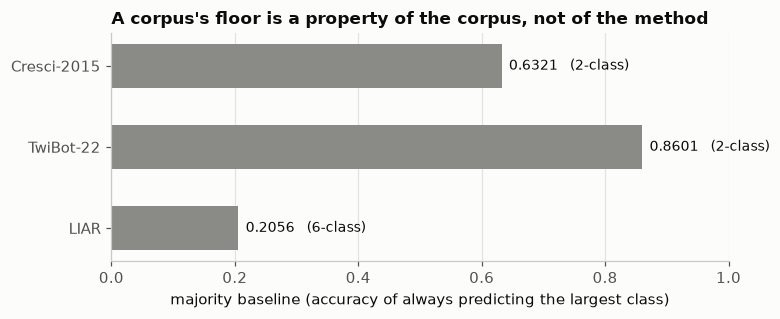

In [3]:
# --- Chart: where each corpus's floor sits ---------------------------------
fig, ax = plt.subplots(figsize=(7.2, 3.0))
d = CORPORA.dropna(subset=["majority_baseline"]).iloc[::-1]
bars = ax.barh(d["corpus"], d["majority_baseline"], color=C["grey"], height=0.55)
for y, (v, k) in enumerate(zip(d["majority_baseline"], d["n_classes"])):
    ax.text(v + 0.012, y, f"{v:.4f}   ({k}-class)", va="center",
            fontsize=9, color=C["ink"])
ax.set_xlim(0, 1.0)
ax.set_xlabel("majority baseline (accuracy of always predicting the largest class)")
ax.set_title("A corpus's floor is a property of the corpus, not of the method")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Figure 1.** Read this as: any accuracy reported on TwiBot-22 over the full
corpus that is below 0.860 has been beaten by a classifier that ignores its
input. The floors differ by a factor of four across these corpora, so accuracies
from different corpora are not comparable at all — and, as notebook 03 shows,
neither are accuracies from different *splits* of the same corpus.

## 4. The architectures

### bot-detection — concatenate a graph branch and a text branch

```
  5 metadata numbers ──► untrained SAGEConv(5→128) ──► 128 dims ─┐
                                                                 ├─► concat 896 ─► linear SVM
  tweets ──► BERT / DistilBERT, mean-pooled ─────────► 768 dims ─┘
```

Two details are stated in the paper and easy to miss, and both matter more than
the architecture:

- the SAGEConv layer is **never trained** (Sect. 3.5: *"training epochs and
  optimization tasks are not required due to the lack of a prediction head"*);
- the classifier is a **linear** SVM (Sect. 3.7, *"relying on the inherent
  separability in this transformed space"*).

Notebook 01 shows what each of these costs.

### entropia — a Rényi entropy feature inside a link-prediction pipeline

The paper's object is a **dynamic time-weighted Rényi entropy** (DTWRE). For each
node, take the degree distribution of its neighbourhood in a temporal snapshot,
compute $H_\alpha$ of it, and weight snapshots by $e^{-\lambda(t - t_k)}$ so that
recent structure counts more. That entropy is one feature block inside a
67-dimensional GraphSAGE link-prediction pipeline on CollegeMsg.

Two knobs: **α**, the Rényi order (the paper reports 0.6 as optimal), and **λ**,
the time-decay constant (the paper reports 1.2). Notebook 02 sweeps both.

The paper's *contribution* is the time weighting — so the ablation that isolates
it is DTWRE against a **static** Rényi entropy. Hold on to that; it is F4.

### desinformation — a survey, so the replication is different in kind

A survey has no experiments. The replication therefore has three independent
layers: it renders the six figures from encoded structures, transcribes Tables
1–4 and states the prose claims as checkable predicates, and implements the
paper's Equations 2–10 as printed. What it contributes to this series is a
feature ablation on Twitter15 (notebook 03, §7) and a set of GNN comparisons on
LIAR that sit two to four points above a six-class majority baseline.

## 5. Did the replications work?

Yes, in the narrow sense that matters: the pipelines run and the headline numbers
come out close. That is the precondition for everything else — a criticism from a
replication that failed to replicate is worth nothing.

In [4]:
# --- Verified constants: replication vs published ---------------------------
# EVIDENCE-INDEX.md sect. 2, results_replicate.csv: GraphSage+BERT 896-dim, 5-fold CV
# 04-PROTOCOL-AND-FLOORS.md sect. 1: the source paper's own comparison table spans
#   77.08 -> 98.68 accuracy, 98.68 being its own headline row.
# EVIDENCE-INDEX.md sect. 5: dtwre published AUC 0.9742 (PAPER_TABLE1);
#   measured mean AUC over 10 seeds 0.8403916211293261 (significance_auc.json)
REPLICATION = pd.DataFrame([
    ("bot-detection", "Cresci-2015 accuracy, 5-fold CV", 0.9868, 0.9789, 0.6321),
    ("entropia",      "CollegeMsg AUC, DTWRE",           0.9742, 0.8404, float("nan")),
], columns=["package", "quantity", "published", "replicated", "majority_baseline"])
REPLICATION["difference"] = REPLICATION["replicated"] - REPLICATION["published"]
print(REPLICATION.to_string(index=False))

      package                        quantity  published  replicated  majority_baseline  difference
bot-detection Cresci-2015 accuracy, 5-fold CV     0.9868      0.9789             0.6321     -0.0079
     entropia           CollegeMsg AUC, DTWRE     0.9742      0.8404                NaN     -0.1338


Two different outcomes, and the difference is instructive.

**bot-detection reproduces.** 0.9789 against a published 0.9868, on the same
protocol — inside a couple of fold standard deviations, and the ordering of the
paper's variants is preserved. The replication is a faithful one, which is why
its *additional* measurements (notebook 01) are worth taking seriously.

**entropia does not reproduce in absolute level.** The replication measures
0.8404 mean AUC over 10 seeds where the paper reports 0.9742. That gap is large
and it is not explained here; several implementation decisions the paper leaves
open are recorded in `docs/DISCREPANCIES.md`. What notebook 02 uses from this
replication is therefore **not** its absolute level but its *internal*
comparisons — α against α, DTWRE against its own ablation, all measured under one
pipeline with error bars. Those comparisons are valid whatever the offset, and
they are the ones the paper itself never made.

**The survey** has no headline number to reproduce. Of its six checkable prose
claims, five hold and one does not (notebook 03, §8).

## 6. The five findings, named

You now have enough vocabulary for the map. Each of these is a measured number in
this repository, and each is the subject of one of the next three notebooks.

| # | Finding | The number | Notebook |
|---|---|---|---|
| **F1** | The text branch is nearly free-standing, and the graph branch is nearly free | BERT alone **0.9730**; five metadata numbers + an MLP **0.9775**; the full 896-dim pipeline **0.9779** | 01 |
| **F2** | The "GraphSage embedding" is 128 columns of rank 10, and is never trained | rank **10**, σ₁₀/σ₁₁ = 6.8 × 10⁶; training the layer is worth **−0.0036** | 01 |
| **F3** | Rényi's α has no measurable effect on the task it was introduced for | AUC spread **0.0098** across α ∈ [0.2, 5]; seed-to-seed σ **0.0179** | 02 |
| **F4** | The paper's own novelty is not significant against its own ablation | DTWRE vs static Rényi: **+0.0035**, 6/10 wins, **p = 0.625** | 02 |
| **F5** | Protocol and baseline choices dominate method choices | 5-fold CV vs official split: **9.2 points**. TwiBot-22: **8 of 8** published rows sit below the majority baseline | 03 |

Two noise floors are used throughout the series, because a difference below them
is not a difference:

| Pipeline | Noise floor | Source |
|---|---|---|
| bot-detection (Cresci-2015) | fold σ ≈ **0.0063** | `results_replicate.csv`, `accuracy_std` |
| entropia (CollegeMsg) | seed σ ≈ **0.0179** | `significance_auc.json`, 10 seeds, DTWRE row |

In [5]:
# --- Verified constants: the two noise floors -------------------------------
# EVIDENCE-INDEX.md sect. 2, results_replicate.csv -> GraphSage+SVM accuracy_std
FOLD_SIGMA_BOT = 0.006348975042113
# EVIDENCE-INDEX.md sect. 5, significance_auc.json -> dtwre row SD over 10 seeds
SEED_SIGMA_ENTROPIA = 0.0179144

print(f"bot-detection fold sigma : {FOLD_SIGMA_BOT:.4f}")
print(f"entropia seed sigma      : {SEED_SIGMA_ENTROPIA:.4f}")
print()
print("Rule used everywhere in this series:")
print("  an effect smaller than the noise floor of its own pipeline is not an effect,")
print("  regardless of its p-value.")

bot-detection fold sigma : 0.0063
entropia seed sigma      : 0.0179

Rule used everywhere in this series:
  an effect smaller than the noise floor of its own pipeline is not an effect,
  regardless of its p-value.


## 7. Three reading rules, inherited

These are applied to every number in the series, including the numbers produced
by the project that criticises the papers.

1. **A majority baseline is printed beside every accuracy.** Always.
2. **An effect smaller than the measured seed-to-seed σ is not an effect.**
3. **A protocol label is attached to every number.** 5-fold CV, official split
   and cross-dataset are three different tasks, and the gap between them here is
   larger than the gap between competing published methods.

## What this licenses

- Reading the rest of this series. Nothing in this notebook is a finding; it is definitions, corpus balances and architecture descriptions.
- The statement that the bot-detection replication reproduces its paper's headline (0.9789 vs 0.9868, 5-fold CV, majority baseline 0.6321).
- The statement that the entropia replication does **not** reproduce the published absolute AUC (0.8404 over 10 seeds vs 0.9742 published), and that only its internal comparisons are used later.

## What this does NOT license

- *"The three papers are wrong."* Nothing here or later in the series establishes that. The findings are about what the published **comparisons** can and cannot isolate.
- *"These methods do not work."* Where a floor is correctly identified, the methods generally clear it. The problem is that the floors and protocols are frequently not stated.
- Any claim about a corpus not listed in §3. Everything in this series is Cresci-2015, TwiBot-20/22, CollegeMsg, LIAR, Twitter15/16, PHEME and CED.
- Any claim about **AI-generated text**. Every corpus here is 2015–2022 and carries no ground truth for machine-generated text. This is an explicit non-goal of the follow-on project (`02-ext-research/docs/00-CHARTER.md` §4).

---

**Next:** [01 — the saturated benchmark](01-the-saturated-benchmark.ipynb), where
the 128-dimensional graph embedding is rebuilt in fifteen lines of numpy and its
rank is measured on screen.